# 10 Investment Priority Analysis

## Purpose

This notebook creates a simple transit investment priority score for selected high-ridership METRO Houston routes.

Earlier notebooks created route-level metrics such as average weekday boardings, scheduled trips, and riders per scheduled trip. This notebook combines those metrics into a ranking framework that helps identify corridors that may warrant additional service improvements or capital investment.

## Inputs

- `data/processed/route_investment_metrics.csv`

## Outputs

- Updated `data/processed/route_investment_metrics.csv` with an `investment_score` column
- Bar chart comparing selected routes by investment priority

## Why This Matters

A transit agency has limited operating and capital resources. A scoring framework helps compare corridors using consistent metrics rather than relying only on total ridership or anecdotal assumptions.


## 1. Load Route Investment Metrics

This section loads the processed route-level dataset created in earlier notebooks. The dataset includes average weekday ridership, scheduled trips, and riders per scheduled trip.

In [1]:
import pandas as pd

routes = pd.read_csv(
    "../data/processed/route_investment_metrics.csv"
)

routes.head()

,route_long_name,route_type,route_text_color,route_color,agency_id,route_id,route_url,route_desc,route_short_name,avg_weekday_boardings,scheduled_trips,riders_per_trip
0,Richmond,3,FFFFFF,4080,HOU,25,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,25,7489,942.0,7.950106
1,Gessner,3,FFFFFF,4080,HOU,46,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,46,7670,854.0,8.981265
2,Westheimer,3,FFFFFF,4080,HOU,82,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,82,14054,1487.0,9.451244
3,Bellaire,3,FFFFFF,4080,HOU,2,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,2,7590,1013.0,7.492596
4,Beechnut,3,FFFFFF,4080,HOU,4,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,4,8743,896.0,9.757812


## 2. Calculate Investment Priority Score

The investment score is calculated by combining ridership demand and route productivity.

Routes with both high average weekday boardings and high riders per scheduled trip receive higher scores. This helps identify corridors where demand is strong relative to the amount of service provided.

In [2]:
routes["investment_score"] = (
    routes["avg_weekday_boardings"] *
    routes["riders_per_trip"]
)

routes[
    [
        "route_long_name",
        "avg_weekday_boardings",
        "scheduled_trips",
        "riders_per_trip",
        "investment_score"
    ]
].sort_values(
    "investment_score",
    ascending=False
)

,route_long_name,avg_weekday_boardings,scheduled_trips,riders_per_trip,investment_score
2,Westheimer,14054,1487.0,9.451244,132827.784802
4,Beechnut,8743,896.0,9.757812,85312.554688
1,Gessner,7670,854.0,8.981265,68886.299766
0,Richmond,7489,942.0,7.950106,59538.345011
3,Bellaire,7590,1013.0,7.492596,56868.805528


## 4. Visualize Investment Priority

A bar chart makes the investment ranking easier to interpret and helps communicate the results to non-technical audiences.

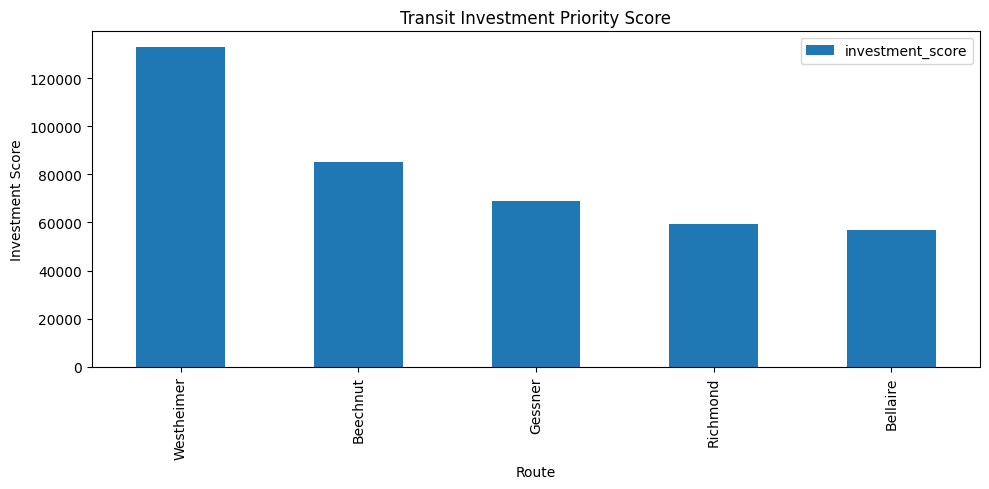

In [3]:
import matplotlib.pyplot as plt

routes.sort_values(
    "investment_score",
    ascending=False
).plot(
    x="route_long_name",
    y="investment_score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Transit Investment Priority Score")
plt.ylabel("Investment Score")
plt.xlabel("Route")

plt.tight_layout()
plt.show()

## Summary

This notebook creates a first-pass investment priority ranking for selected METRO Houston routes.

The score is intentionally simple and transparent. It is not meant to replace a full planning model, but it provides a defensible starting point for comparing corridors using ridership demand and service productivity.

The results from this notebook are used in the final recommendations section of the project.
